In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pickle
from gymnasium.envs.toy_text.frozen_lake import generate_random_map

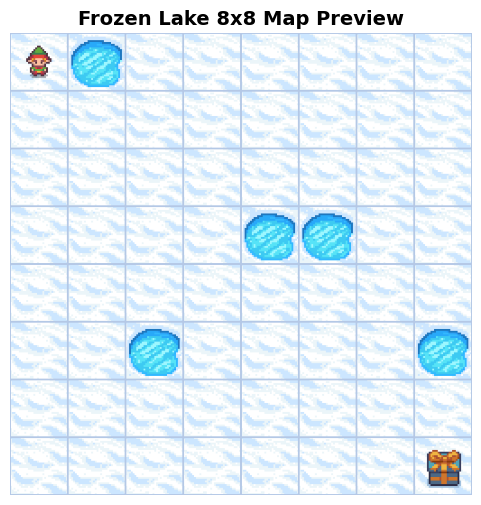

In [7]:
random_map = generate_random_map(size=8, p=0.9) # Generate an 8x8 map that is mathematically guaranteed to be solvable
# p=0.8 means 95% safe ice, 5% holes

env = gym.make('FrozenLake-v1', desc = random_map, is_slippery = True, success_rate = 1.0/3.0, render_mode = 'rgb_array')
first_state, info = env.reset()
frame = env.render()

plt.figure(figsize=(6, 6))
plt.imshow(frame)
plt.axis('off') 
plt.title("Frozen Lake 8x8 Map Preview", fontsize=14, fontweight='bold')
plt.show()


q_table = np.zeros(shape = (env.observation_space.n, env.action_space.n)) # init a 64 x 4 2d Array

learning_rate = 0.01 # alpha
discount_factor = 0.99 # gamma
epsilon = 1.0 # random actions
min_epsilon = 0.1
epsilon_decay_rate = 0.0001
n_episodes = 20000

reward_per_episode = np.zeros(n_episodes)

# Training 

In [8]:
for i in range(n_episodes):
    # print(f'Episode {i + 1}')

    state, info = env.reset()
    terminated, truncated = False, False

    reward_in_the_episode = 0

    while (not terminated and not truncated):
        # Policy
        if np.random.random() < epsilon: # Exploration
            action = env.action_space.sample()
        else: # Exploitation
            action = np.argmax(q_table[state])
        # 0: left
        # 1: down 
        # 2: right
        # 3: up
        new_state, reward, terminated, truncated, info =  env.step(action = action)
        reward_in_the_episode += reward

        if terminated:
            target = reward # Just the final reward (0 or 1)
        else:
            target = reward + discount_factor * np.max(q_table[new_state])
        
        q_table[state][action] += learning_rate * (target - q_table[state][action])

        state = new_state
        # print(f'action: {action}, new_state: {new_state}, reward: {reward}, terminated: {terminated}, truncated: {truncated}')

    reward_per_episode[i] = reward_in_the_episode
    epsilon = max(epsilon - epsilon_decay_rate, min_epsilon) # decay epsilon until 0

    if (reward == 1): # At the end of the episode, if we finish - reward = 1
        reward_per_episode[i] = 1

env.close()

# Running Diagnostics

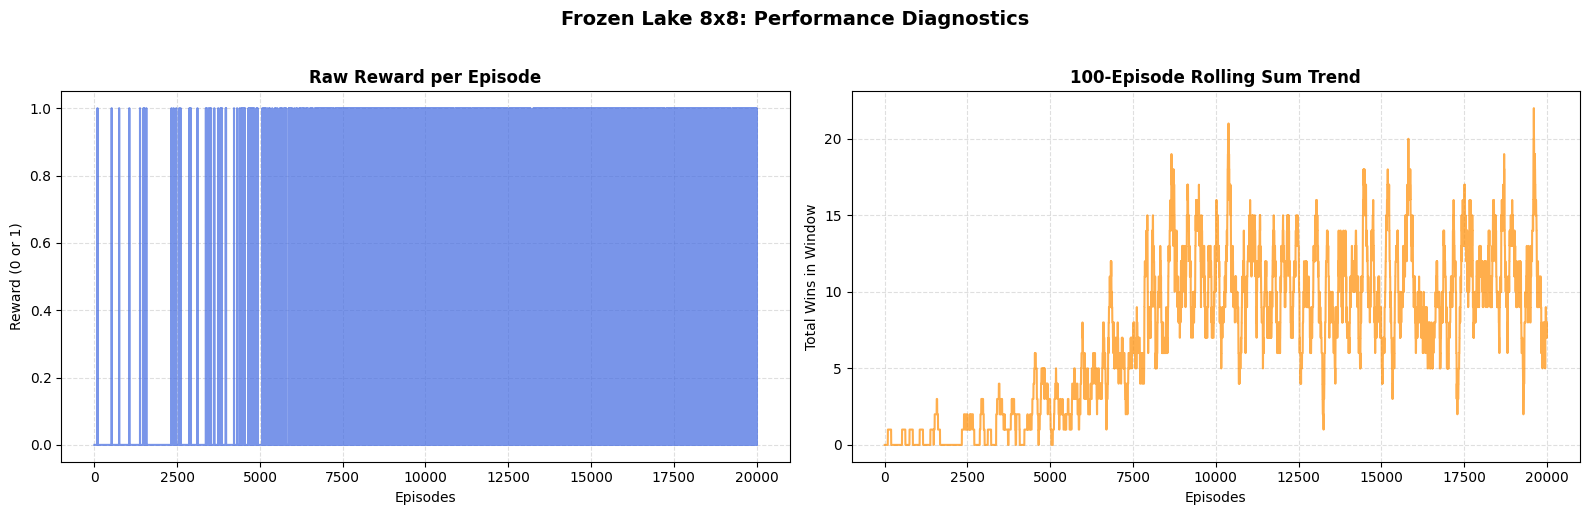

[[6.02051316e-02 3.40556610e-02 3.49901783e-02 3.50344922e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [9.74344763e-04 2.30771495e-02 1.68597558e-03 1.55698504e-03]
 [3.42678195e-02 4.18828610e-03 3.34476174e-03 3.45000042e-03]
 [3.22551958e-03 2.54642577e-10 8.14368782e-06 1.40467556e-07]
 [3.55791331e-05 1.15965883e-10 1.18246550e-05 3.80562984e-08]
 [9.05925840e-06 3.84700953e-10 1.41191235e-10 6.53848342e-11]
 [3.65014307e-11 8.90783349e-08 3.29709647e-12 4.63921638e-11]
 [4.87955220e-02 4.55776794e-02 6.32260242e-02 3.92769562e-02]
 [2.00922436e-02 3.03342432e-02 4.56679169e-02 1.95600521e-02]
 [1.57861558e-02 5.83004081e-02 1.58404643e-02 1.33526143e-02]
 [5.18813438e-02 8.83807079e-03 1.00178715e-02 9.60314781e-03]
 [8.12639973e-04 1.11707274e-02 2.01891001e-06 1.01906862e-03]
 [1.29435889e-04 1.44090993e-03 3.99097374e-05 3.26754884e-05]
 [1.17034346e-05 9.65899607e-04 8.03939681e-05 1.59560670e-06]
 [5.52384576e-06 1.80724449e-04 1.04298665e-08 2.448665

In [9]:
sum_rewards = np.zeros(n_episodes)
for t in range(n_episodes):
    sum_rewards[t] = np.sum(reward_per_episode[max(0,t-100):(t+1)]) # 100-episode rolling window sum of rewards

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Graph 1: Raw Reward per Episode
ax1.plot(reward_per_episode, color='royalblue', alpha=0.7)
ax1.set_title('Raw Reward per Episode', fontsize=12, fontweight='bold')
ax1.set_xlabel('Episodes')
ax1.set_ylabel('Reward (0 or 1)')
ax1.grid(True, linestyle='--', alpha=0.4) # of the grid in the background

# Graph 2: 100-Episode Rolling Sum
ax2.plot(sum_rewards, color='darkorange', alpha = 0.7)
ax2.set_title('100-Episode Rolling Sum Trend', fontsize=12, fontweight='bold')
ax2.set_xlabel('Episodes')
ax2.set_ylabel('Total Wins in Window')
ax2.grid(True, linestyle='--', alpha=0.4)

# 3. Save and clean up the display layout
plt.suptitle('Frozen Lake 8x8: Performance Diagnostics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout() 
plt.savefig('frozen_lake8x8_separated.png', dpi=300, bbox_inches='tight') 
plt.show()


f = open('frozen_lake8x8.pk1', 'wb')
pickle.dump(q_table,f) # Saving the Q_Table
f.close()


# view the q_table normally
with open('frozen_lake8x8.pk1', 'rb') as f:
    loaded_q_table = pickle.load(f)
print(loaded_q_table)